In [22]:
# Tools from LangChain community
from langchain_community.tools import ArxivQueryRun, WikipediaQueryRun
from langchain_community.utilities import ArxivAPIWrapper, WikipediaAPIWrapper
from langchain_community.tools.tavily_search import TavilySearchResults

# Initialize Arxiv tool
arxiv = ArxivQueryRun(
    api_wrapper=ArxivAPIWrapper(top_k_results=2, doc_content_chars_max=500)
)

# Initialize Wikipedia tool
wiki = WikipediaQueryRun(
    api_wrapper=WikipediaAPIWrapper(top_k_results=1, doc_content_chars_max=500)
)

# Initialize Tavily search tool
tavily = TavilySearchResults()

# Simple math functions
def multiply(a: int, b: int) -> int:
    """Multiply a and b."""
    return a * b

def add(a: int, b: int) -> int:
    """Add a and b."""
    return a + b

def divide(a: int, b: int) -> float:
    """Divide a and b."""
    return a / b

# Collect all tools in a list
tools = [arxiv, wiki, tavily, add, divide, multiply]


In [23]:
response = arxiv.invoke("Attention iss all you need")
response

'Published: 2021-05-06\nTitle: Do You Even Need Attention? A Stack of Feed-Forward Layers Does Surprisingly Well on ImageNet\nAuthors: Luke Melas-Kyriazi\nSummary: The strong performance of vision transformers on image classification and other vision tasks is often attributed to the design of their multi-head attention layers. However, the extent to which attention is responsible for this strong performance remains unclear. In this short report, we ask: is the attention layer even necessary? Specifi'

In [25]:
response = wiki.invoke("What is machine learning")
response

'Page: Machine learning\nSummary: Machine learning (ML) is a field of study in artificial intelligence concerned with the development and study of statistical algorithms that can learn from  data and generalize to unseen data, and thus perform tasks without being explicitly programmed.\nStatistics and mathematical optimisation methods compose the foundations of machine learning. Data mining is a related field of study, focusing on exploratory data analysis (EDA) through unsupervised learning.\nFrom '

In [26]:
from langchain_groq import ChatGroq
from dotenv import find_dotenv
from dotenv import load_dotenv
# Load environment variables (ensure GROQ_API_KEY is set in your .env)
load_dotenv(find_dotenv())

# Initialize Groq model
llm = ChatGroq(
    model="qwen/qwen3.8-27b",
    temperature=0.7,
)

llm_with_tools = llm.bind_tools(tools)

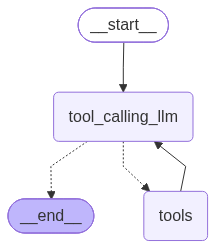

In [ ]:
from typing import TypedDict
from langgraph.prebuilt import tools_condition
from langgraph.constants import START
from langgraph.prebuilt import ToolNode
from langgraph.graph import StateGraph
from typing import Annotated
from langchain_core.messages import AnyMessage
from langgraph.graph import add_messages

class State(TypedDict):
    messages : Annotated[list[AnyMessage], add_messages]

def tool_calling_llm(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

builder = StateGraph(State)
#node
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))
#edges
builder.add_edge(START, "tool_calling_llm")

"""
tools_condition ->
LangGraph's built-in tools_condition helper instead of a hand-written function — it checks the same thing (does the last AI
message contain tool_calls?) and is the standard, idiomatic way to wire a ToolNode once you have
more than one or two tools.
"""

builder.add_conditional_edges("tool_calling_llm", tools_condition)
builder.add_edge("tools", "tool_calling_llm")
#build
graph = builder.compile()
graph

In [28]:
from langchain_core.messages.human import HumanMessage
response = graph.invoke({"messages": HumanMessage("Provide me the top 10 recent AI news for March 3rd 2025, add 5 plus 5 and then multiply by 10")})
response

{'messages': [HumanMessage(content='Provide me the top 10 recent AI news for March 3rd 2025, add 5 plus 5 and then multiply by 10', additional_kwargs={}, response_metadata={}, id='855a1953-bf47-42fb-b24f-f27bf202782b'),
  AIMessage(content='Here are the top 10 recent AI news items for March 3rd, 2025, followed by the mathematical calculation you requested.\n\n### Top 10 AI News for March 3, 2025\n\n1.  **OpenAI Launches GPT-4o Mini:** OpenAI officially released GPT-4o mini, a smaller, faster, and more affordable version of its flagship multimodal model, aiming to bring advanced AI capabilities to a broader range of developers and users.\n2.  **Google DeepMind Advances Gemini 1.5 Pro:** Google announced significant updates to Gemini 1.5 Pro, highlighting its improved ability to handle long-context windows (up to 10 million tokens) and enhanced reasoning capabilities for complex tasks.\n3.  **Microsoft Builds Custom AI Chips:** Microsoft confirmed the development of its next-generation i

In [29]:
from langchain_core.messages.human import HumanMessage
response = graph.invoke({"messages": HumanMessage("Multiply by 500 into that")})
response

{'messages': [HumanMessage(content='Multiply by 500 into that', additional_kwargs={}, response_metadata={}, id='35a20571-7831-4c60-bc2b-2501d5b1fd04'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'tn3c2s6df', 'function': {'arguments': '{"a":1,"b":500}', 'name': 'multiply'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 38, 'prompt_tokens': 724, 'total_tokens': 762, 'completion_time': 0.074047478, 'completion_tokens_details': None, 'prompt_time': 0.051132749, 'prompt_tokens_details': None, 'queue_time': 0.04819049, 'total_time': 0.125180227}, 'model_name': 'qwen/qwen3.8-27b', 'system_fingerprint': 'fp_21e59ac2de', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a0ae14-d0c8-7f90-970a-917c3f6b9909-0', tool_calls=[{'name': 'multiply', 'args': {'a': 1, 'b': 500}, 'id': 'tn3c2s6df', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 724, 'out

In [30]:
from langgraph.checkpoint.memory import MemorySaver
memory = MemorySaver()
graph_memory = builder.compile(checkpointer=memory)
config = {"configurable": {"thread_id": "1"}}

response = graph_memory.invoke({"messages": [HumanMessage("Add 12 and 13.")]}, config=config)
response

{'messages': [HumanMessage(content='Add 12 and 13.', additional_kwargs={}, response_metadata={}, id='34b3483d-1ce3-4c03-b627-8e1da96823cf'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'afjst58dc', 'function': {'arguments': '{"a":12,"b":13}', 'name': 'add'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 37, 'prompt_tokens': 725, 'total_tokens': 762, 'completion_time': 0.077335347, 'completion_tokens_details': None, 'prompt_time': 0.059006972, 'prompt_tokens_details': None, 'queue_time': 0.103070687, 'total_time': 0.136342319}, 'model_name': 'qwen/qwen3.8-27b', 'system_fingerprint': 'fp_a1293f40b5', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a0ae17-9a6a-7171-b818-38a08e5e3c7b-0', tool_calls=[{'name': 'add', 'args': {'a': 12, 'b': 13}, 'id': 'afjst58dc', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 725, 'output_tokens': 37, 'to

In [31]:
response = graph_memory.invoke({"messages": [HumanMessage("add that number to 25")]}, config=config)
response

{'messages': [HumanMessage(content='Add 12 and 13.', additional_kwargs={}, response_metadata={}, id='34b3483d-1ce3-4c03-b627-8e1da96823cf'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'afjst58dc', 'function': {'arguments': '{"a":12,"b":13}', 'name': 'add'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 37, 'prompt_tokens': 725, 'total_tokens': 762, 'completion_time': 0.077335347, 'completion_tokens_details': None, 'prompt_time': 0.059006972, 'prompt_tokens_details': None, 'queue_time': 0.103070687, 'total_time': 0.136342319}, 'model_name': 'qwen/qwen3.8-27b', 'system_fingerprint': 'fp_a1293f40b5', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a0ae17-9a6a-7171-b818-38a08e5e3c7b-0', tool_calls=[{'name': 'add', 'args': {'a': 12, 'b': 13}, 'id': 'afjst58dc', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 725, 'output_tokens': 37, 'to